#### Imports

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

#### Generate Data ( noisy data arround 0 and 1)

In [ ]:
def generate_xor_data(n_samples=200, noise=0.1):
    centers = np.array([
        [0, 0], 
        [0, 1], 
        [1, 0], 
        [1, 1]  
    ])
    labels = np.array([0, 1, 1, 0])
    
    X_list = []
    y_list = []
    
    points_per_cluster = n_samples // 4
    
    for i, center in enumerate(centers):
        cluster_points = np.random.normal(loc=center, scale=noise, size=(points_per_cluster, 2))
        
        X_list.append(cluster_points)
        y_list.append(np.full(points_per_cluster, labels[i]))
    
    X = np.vstack(X_list)
    y = np.hstack(y_list)
    
    return X, y

#### Activation function

In [49]:
def step_func(z):
    return 1 if z >= 0 else 0

#### Perceptron Algo

In [ ]:
def mlp_xor(X):

    # Bias
    b1, b2, b3 = -1.5, -0.5, -0.5
    
    # Hidden Layer
    w1, w3 = 1, 1  
    w2, w4 = 1, 1  
    
    # Output Layer
    w5, w6 = -2, 1 

    predictions = []
    
    for x_sample in X:
        x1, x2 = x_sample[0], x_sample[1]
        
        # SOP1 et SOP2
        h1 = step_func(b1 + (x1 * w1) + (x2 * w3))
        h2 = step_func(b2 + (x1 * w2) + (x2 * w4))
        

        # SOP3
        y_hat = step_func(b3 + (h1 * w5) + (h2 * w6))
        
        predictions.append(y_hat)
            
    return np.array(predictions)

#### Implementation

In [ ]:
# Data
X, y = generate_xor_data(n_samples=200, noise=0.1)

# Predict
y_pred = mlp_xor(X)

# Accuracy
accuracy = np.mean(y == y_pred)
print(f"Accuracy on noisy data: {accuracy * 100:.2f}%")

# Display
df = pd.DataFrame(X, columns=['x1', 'x2'])
df['True'] = y
df['Pred'] = y_pred
print("\nSample Data:")
print(df.head())

Accuracy on noisy data: 100.00%

Sample Data:
         x1        x2  True  Pred
0 -0.059738 -0.154691     0     0
1 -0.015220  0.022050     0     0
2  0.006660 -0.130789     0     0
3  0.193888  0.000688     0     0
4  0.081991  0.094322     0     0


#### Boundry

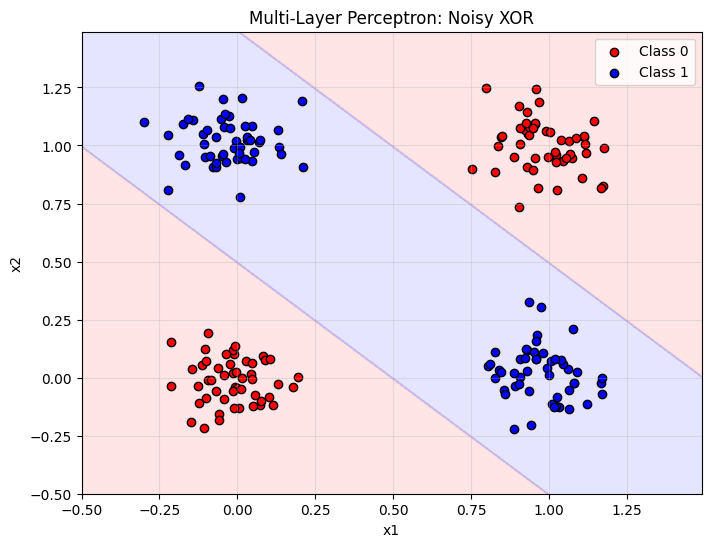

In [56]:
def plot_xor_boundary(X, y):
    x_min, x_max = -0.5, 1.5
    y_min, y_max = -0.5, 1.5
    
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))
    
    Z = mlp_xor(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    

    plt.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(['#FFAAAA', '#AAAAFF']))
    
    # Class 0 
    plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], c='red', edgecolor='k', label='Class 0')
    
    # Class 1
    plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], c='blue', edgecolor='k', label='Class 1')
    
    plt.title('Multi-Layer Perceptron: Noisy XOR')
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_xor_boundary(X, y)